In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/01-TrackLength/"

In [3]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "very_long_prot":1200, 
}

In [4]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
elongation_rate = 5
for i in range(10):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if i == 0:
        datas = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5.csv"))

In [5]:
# datas = pd.read_csv(os.path.join(path, "datas_track_length.csv"), index_col="Unnamed: 0")
datas

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
0,0.0,1451.175879,0
1,0.1,1451.577889,0
2,0.2,1451.979899,0
3,0.3,1452.381910,0
4,0.4,1452.783920,0
...,...,...,...
8399995,83999.5,1586.814070,9
8399996,83999.6,1587.055276,9
8399997,83999.7,1587.296482,9
8399998,83999.8,1587.537688,9


In [40]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
first = True

for t in [10,30,50,100]:
# t = 50

    dt = t*0.1
    for length_track in [30,60,300,600,1200,1800,2700,3600]:
        print(length_track)
        
        for i in range(10):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
            datas2["FRAME"] = np.arange(length_track)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [30,60,300,600,1200,1800,2700,3600]):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, 
                 y_auto, 
                 k, c,
                 elongation_r, 
                 translation_init_r,
                 perr) = single_track_analysis(x, 
                                             y, 
                                             delta_t = dt,
                                             protein_size=prot_aa_size["very_long_prot"],
                                             suntag_size =prot_aa_size["32xsuntag"], 
                                             repetition_suntag = 32,
                                             mm=None,
                                             method="exact",
                                             simulation=True)
                if first:
                    results = pd.DataFrame({"elongation_r":elongation_r, 
                                            "init_translation_r":translation_init_r, 
                                            "dt":dt,
                                            "long_track":datas2.shape[0],
                                            "k":k,
                                            "c":c,
                                           "id":i},
                                          index=[0])
                    first = False
                
                else:
                    results = pd.concat([results, 
                                    pd.DataFrame({"elongation_r":elongation_r, 
                                                  "init_translation_r":translation_init_r, 
                                                  "dt":dt, 
                                                  "long_track":datas2.shape[0],
                                                  "k":k,
                                                    "c":c,
                                                  "id":i}, index=[0])
                                    ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"))

30
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
60
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
300
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
600
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
1200
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
1800
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
2700
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
3600
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
30
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
60
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
300
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
600
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
1200
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
1800
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
2700
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
3600
50 32
Sorry, due to the complexi

In [35]:
# results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_24.csv"), index_col="Unnamed: 0")

In [41]:
results.groupby(by=['dt', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].mean()

elongation_r  init_translation_r         k           c
dt   long_track                                                        
1.0  30            141.989100          167.340819  5.708105  167.340819
     60             96.292733           66.033102  3.871065   66.033102
     300            19.750077            0.646809  0.793973    0.646809
     600            11.056933            0.182071  0.444500    0.182071
     1200            8.892030            0.177436  0.357469    0.177436
     1800            8.056172            0.152840  0.323866    0.152840
     2700            7.334678            0.118812  0.294861    0.118812
     3600            7.027241            0.101133  0.282502    0.101133
3.0  30             93.015036           41.293522  3.739298   41.293522
     60             45.261032            7.261707  1.819539    7.261707
     300             8.945030            0.156880  0.359599    0.156880
     600             8.057038            0.152662  0.323901    0.152662
     1200            7.027375            0.101104  0.282508    0.101104
     1800            5.453653            0.069387  0.219242    0.069387
     2700            5.029587            0.061268  0.202194    0.061268
     3600                 NaN                 NaN       NaN         NaN
5.0  30             53.278877           11.471577  2.141864   11.471577
     60             19.912744            0.649318  0.800512    0.649318
     300             8.395852            0.144520  0.337522    0.144520
     600             7.332326            0.117353  0.294767    0.117353
     1200            5.418862            0.067591  0.217844    0.067591
     1800            5.159241            0.060352  0.207407    0.060352
     2700                 NaN                 NaN       NaN         NaN
     3600                 NaN                 NaN       NaN         NaN
10.0 30             19.945244            0.651477  0.801819    0.651477
     60             11.089934            0.182262  0.445826    0.182262
     300             7.335584            0.116937  0.294898    0.116937
     600             5.419987            0.067576  0.217889    0.067576
     1200                 NaN                 NaN       NaN         NaN
     1800                 NaN                 NaN       NaN         NaN
     2700                 NaN                 NaN       NaN         NaN
     3600                 NaN                 NaN       NaN         NaN

In [42]:
results.groupby(by=['dt', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].std()

elongation_r  init_translation_r         k           c
dt   long_track                                                        
1.0  30            153.836967          167.107475  6.184401  167.107475
     60             41.259934           62.020000  1.658691   62.020000
     300             4.818980            0.320051  0.193728    0.320051
     600             3.719327            0.105762  0.149521    0.105762
     1200            1.837256            0.123859  0.073860    0.123859
     1800            1.838867            0.092445  0.073924    0.092445
     2700            1.826393            0.078326  0.073423    0.078326
     3600            1.415742            0.062196  0.056914    0.062196
3.0  30             26.783051           35.245309  1.076706   35.245309
     60             23.514059            7.315943  0.945289    7.315943
     300             1.274167            0.096089  0.051223    0.096089
     600             1.850197            0.091908  0.074380    0.091908
     1200            1.418895            0.062097  0.057041    0.062097
     1800            1.840113            0.033906  0.073974    0.033906
     2700            1.844137            0.032517  0.074136    0.032517
     3600                 NaN                 NaN       NaN         NaN
5.0  30             29.486160           11.966890  1.185373   11.966890
     60              5.099591            0.317780  0.205009    0.317780
     300             1.743810            0.089449  0.070103    0.089449
     600             1.714370            0.086424  0.068919    0.086424
     1200            1.888027            0.030010  0.075901    0.030010
     1800            1.675105            0.029017  0.067341    0.029017
     2700                 NaN                 NaN       NaN         NaN
     3600                 NaN                 NaN       NaN         NaN
10.0 30              5.355513            0.335937  0.215297    0.335937
     60              3.732834            0.108249  0.150064    0.108249
     300             1.720414            0.085397  0.069162    0.085397
     600             1.883756            0.029914  0.075729    0.029914
     1200                 NaN                 NaN       NaN         NaN
     1800                 NaN                 NaN       NaN         NaN
     2700                 NaN                 NaN       NaN         NaN
     3600                 NaN                 NaN       NaN         NaN

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


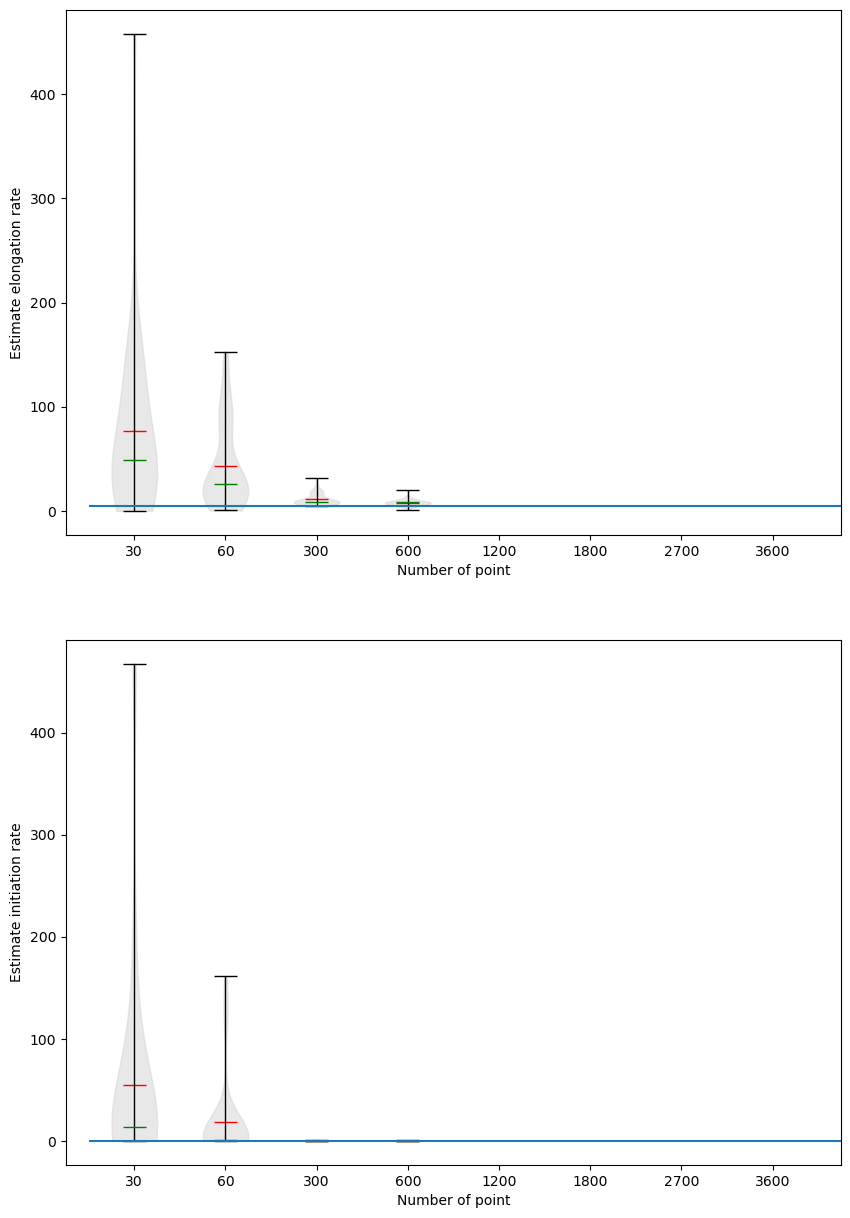

In [43]:
fig, ax = plt.subplots(2,1)


violin = ax[0].violinplot(dataset = [results[ (results.long_track == length_track)]["elongation_r"].values for length_track in [30,60,300,600,1200,1800,2700,3600]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
# results.boxplot(['init_translation_r'] , 
#                by=['dt', "long_track"], 
#                grid=False, 
#                ax = ax[1],
#                rot=90,
#                boxprops=dict(linestyle='-', linewidth=1.5, color="black"),
#                medianprops=dict(linestyle='-', linewidth=1.5, color="red"),
#                )


violin = ax[1].violinplot(dataset = [results[(results.long_track == length_track)]["init_translation_r"].values for length_track in [30,60,300,600,1200,1800,2700,3600]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1

group = ['dt', "long_track"]
column = 'elongation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
group = ['dt', "long_track"]
column = 'init_translation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)

def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Number of point')
# set style for the axes
labels =[30,60,300,600,1200,1800,2700,3600]
for a in ax:
    set_axis_style(a, labels)

ax[0].set_ylabel("Estimate elongation rate")
ax[1].set_ylabel("Estimate initiation rate")

# ax[0].set_ylim(-5,50)
# ax[1].set_ylim(-1, 20)
ax[0].hlines(elongation_rate, 0.5, 9.5)
ax[1].hlines(0.05, 0.5, 9.5)
fig.set_size_inches((10,15))
fig.savefig(os.path.join(path_save, "results_length_boxplot_exact_dt1_0.05_5.eps"), dpi=300)

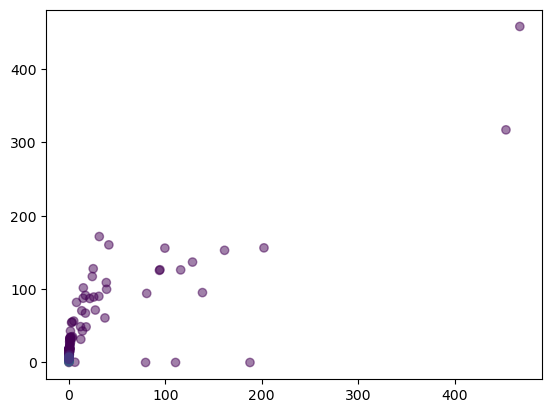

In [44]:
fig, ax = plt.subplots()
ax.scatter(results["init_translation_r"], results["elongation_r"], c=results["long_track"], alpha=0.5)
# ax.set_xlim(0,50)
# ax.set_ylim(0,50)

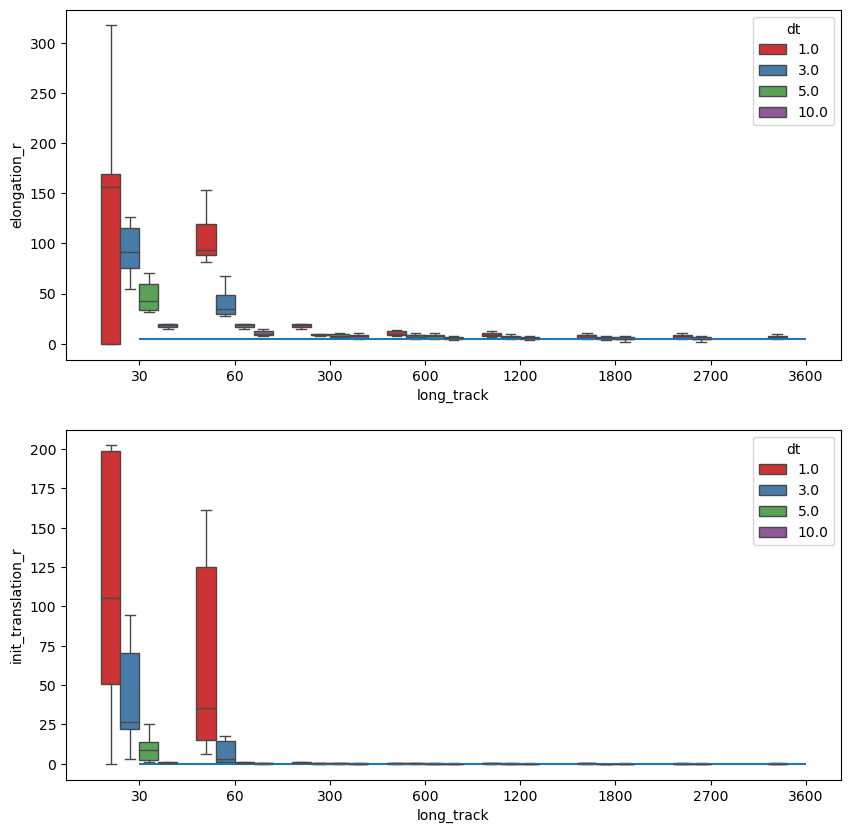

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [78]:
import seaborn as sns

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="long_track", y="elongation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[0])
# axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 7)

sns.boxplot(x="long_track", y="init_translation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[1])
# axes[1].set_ylim(-0.2, 1)
axes[1].hlines(0.05, 0.0, 7)

fig.set_size_inches(10,10)
plt.show()
fig.savefig(os.path.join(path_save, "track_length_dt_v2.eps"), dpi=300)

In [ ]:
results[(results.dt == 60.0) & (results.long_track >1000) & (results.elongation_r>0)]

In [ ]:
results_group = results.groupby(["dt", "long_track"]).mean()
results_group.reset_index(inplace=True)

elongation_ref = 24

results_group["elongation_r_diff"] = elongation_ref-results_group['elongation_r']
results_group["elongation_r_ratio"] = 100*results_group["elongation_r"]/elongation_ref - 100
results_group["elongation_r_ratio"]= np.abs(results_group["elongation_r_ratio"])


results_group["init_translation_r_diff"] = 20-results_group['init_translation_r']
results_group["init_translation_r_ratio"] = 100*results_group["init_translation_r"]/20 -100
results_group["init_translation_r_ratio"] = np.abs(results_group["init_translation_r_ratio"])

results_group

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='elongation_r_ratio')

# Create the heatmap
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
# plt.figure(figsize=(8, 6))
ax1 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100,
                 ax=ax1)
# Invert the y-axis
ax1.invert_yaxis()
ax1.set_title("Heatmap of elongation rate Values")
ax1.set_xlabel("time step")
ax1.set_ylabel("track length")



heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')
ax2 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100, 
                  ax = ax2
                )
# Invert the y-axis
ax2.invert_yaxis()
ax2.set_title("Heatmap of initiation rate Values")
ax2.set_xlabel("time step")
ax2.set_ylabel("track length")

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap=combined_colors,
                 vmin = 0,
                 vmax = 200
                )
# Invert the y-axis
ax.invert_yaxis()

plt.title("Heatmap of initiation rate Values")
plt.xlabel("time step")
plt.ylabel("track length")
plt.show()